In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged.csv')

df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

sentiment_map = {'positive': 1, 'neutral': 0, 'mixed': 0, 'negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_map).fillna(0)

df['Decayed_Sentiment'] = df['Sentiment_Score'] / np.log1p(df['News_Age_Minutes'] + 1)

df['Close_to_SMA50'] = df['Close'] / df['SMA_50']
df['Close_to_EMA10'] = df['Close'] / df['EMA_10']
df['Close_to_Kalman'] = df['Close'] / df['kalman_close']

df['Vol_SMA20'] = df['Volume'].rolling(window=20).mean()
df['Relative_Volume'] = df['Volume'] / df['Vol_SMA20']

range_denom = df['rolling_high_20'] - df['rolling_low_20']
df['Price_Range_Position'] = np.where(
    range_denom == 0, 0.5, (df['Close'] - df['rolling_low_20']) / range_denom
)

minutes_since_midnight = df['Stock_Timestamp'].dt.hour * 60 + df['Stock_Timestamp'].dt.minute
day_minutes = 1440 # 24 * 60
df['Time_Sin'] = np.sin(2 * np.pi * minutes_since_midnight / day_minutes)
df['Time_Cos'] = np.cos(2 * np.pi * minutes_since_midnight / day_minutes)

df['Trans_SMA20'] = df['Transactions'].rolling(window=20).mean()
df['Relative_Transactions'] = df['Transactions'] / df['Trans_SMA20']

df['Returns_1m'] = df['Close'].pct_change()
df['Realized_Volatility'] = df['Returns_1m'].rolling(window=20).std()

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

feature_cols = [
    'RSI_14', 'MACD_12_26_9', 'kalman_diff',    
    'Close_to_SMA50', 'Close_to_EMA10', 'Close_to_Kalman', 
    'Relative_Volume', 'Price_Range_Position',     
    'Relative_Transactions', 'Realized_Volatility',
    'Decayed_Sentiment',                           
    'Time_Sin', 'Time_Cos'                         
]

model_df = df[feature_cols + ['Target']].dropna()

print(f"Feature Engineering Complete. Final Shape: {model_df.shape}")
print(model_df.head())

Feature Engineering Complete. Final Shape: (89970, 14)
       RSI_14  MACD_12_26_9  kalman_diff  Close_to_SMA50  Close_to_EMA10  \
20  50.397598      0.103016    -0.116949        1.000782        0.999693   
21  50.062544      0.084642    -0.212878        1.000736        0.999697   
22  55.537852      0.103584     0.043101        1.001862        1.000644   
23  56.898933      0.126418     0.004952        1.002150        1.000766   
24  60.981591      0.171984     0.219202        1.003029        1.001383   

    Close_to_Kalman  Relative_Volume  Price_Range_Position  \
20         0.999703         1.212529              0.584577   
21         0.999460         1.534339              0.535135   
22         1.000109         0.865374              0.703448   
23         1.000013         0.998561              0.782759   
24         1.000555         0.950923              0.943396   

    Relative_Transactions  Realized_Volatility  Decayed_Sentiment  Time_Sin  \
20               0.818485           

In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler.fit_transform(model_df[feature_cols])

final_data = np.column_stack((scaled_features, model_df['Target'].values))

n = len(final_data)
train_idx = int(n * 0.70)
val_idx = int(n * 0.90) 

train_data = final_data[:train_idx]
val_data = final_data[train_idx:val_idx]
test_data = final_data[val_idx:]

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")

def create_sequences(data, window_size=20):
    X, y = [], []

    for i in range(window_size, len(data)):

        X.append(data[i-window_size:i, :-1])
        
        y.append(data[i, -1])
        
    return np.array(X), np.array(y)

window_size = 20 
X_train, y_train = create_sequences(train_data, window_size)
X_val, y_val = create_sequences(val_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)

print(f"\nFinal LSTM Input Shape (X_train): {X_train.shape}")


Train samples: 62978
Val samples:   17995
Test samples:  8997

Final LSTM Input Shape (X_train): (62958, 20, 13)


C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5000 - loss: 0.6938 - val_accuracy: 0.4974 - val_loss: 0.6942
Epoch 2/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5040 - loss: 0.6933 - val_accuracy: 0.5024 - val_loss: 0.6932
Epoch 3/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5016 - loss: 0.6933 - val_accuracy: 0.4974 - val_loss: 0.6934
Epoch 4/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.4989 - loss: 0.6933 - val_accuracy: 0.5042 - val_loss: 0.6931
Epoch 5/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5003 - loss: 0.6933 - val_accuracy: 0.5076 - val_loss: 0.6931
Epoch 6/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.5020 - val_loss: 0.6931
Epoch 7/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5013 - loss: 0.6932 - val_accuracy: 0.5034 - val_loss: 0.6931
Epoch 8/80
984/984 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5024 - loss: 0.6932 - 

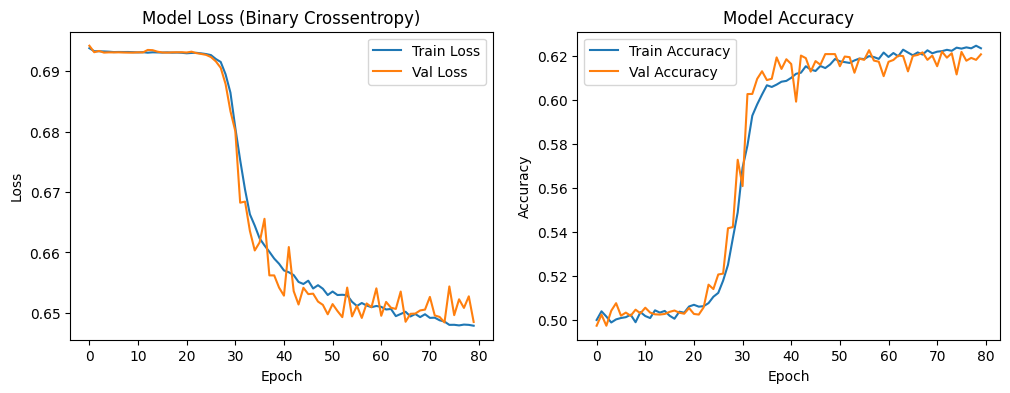

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


def build_stacked_lstm(input_shape, lr=0.001):
    model = Sequential()
 
    model.add(Input(shape=input_shape))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.2))
    
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_stacked_lstm(input_shape)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,          
    batch_size=64,   
    verbose=1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


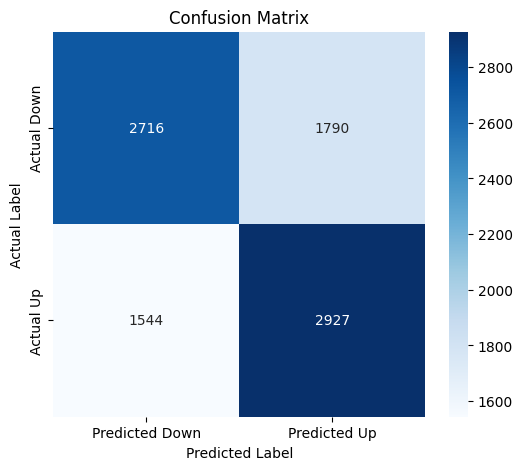


Classification Report:

              precision    recall  f1-score   support

         0.0       0.64      0.60      0.62      4506
         1.0       0.62      0.65      0.64      4471

    accuracy                           0.63      8977
   macro avg       0.63      0.63      0.63      8977
weighted avg       0.63      0.63      0.63      8977



In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


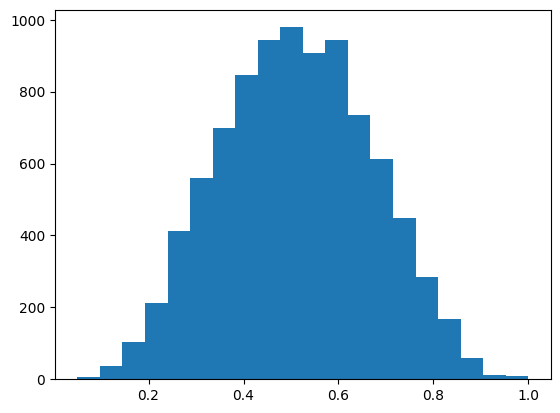

In [6]:
pred_probs = model.predict(X_test)
plt.hist(pred_probs, bins=20)
plt.show()


In [7]:
capital = 10000
# Assuming df_stocks is sorted chronologically and aligned with your target
# Compute next-minute percentage change based on Close price
df['price_change'] = df['Close'].pct_change().shift(-1)  # next-minute return

# Make sure it aligns with y_test
price_change = df['price_change'].values[-len(y_test):]  # take last part matching test set

for i in range(len(y_test)):
    if y_pred[i] == 1:  # buy
        capital *= 1 + price_change[i]  # price_change = % movement next minute
print(f"Simulated capital: {capital}")


Simulated capital: nan



       FINANCIAL PERFORMANCE (WITH SLIPPAGE & COSTS)
Initial Capital:        $10,000.00
Total Profit/Loss:      $11,485.32
Final Capital:          $21,485.32


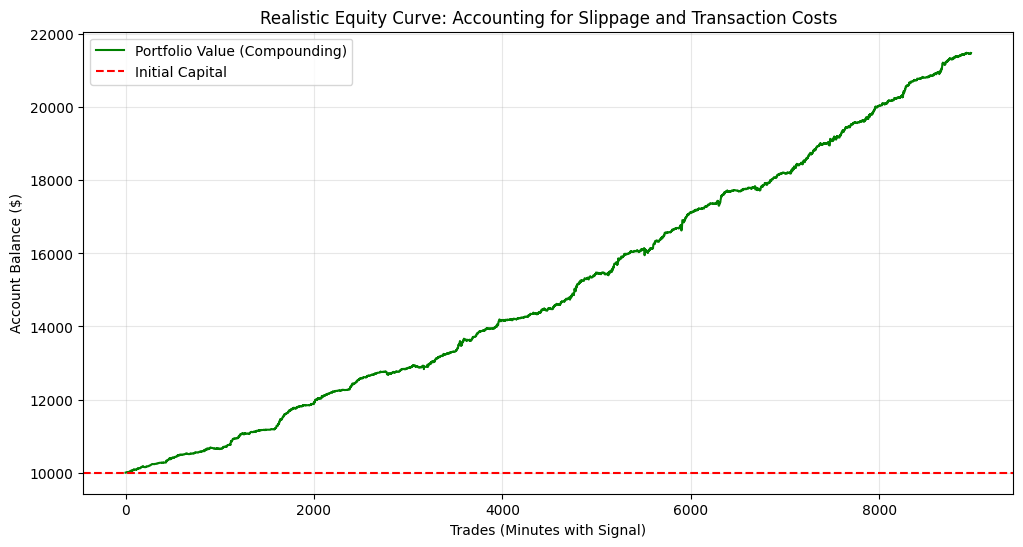

In [8]:
# --- Aligning Test Data for Financial Backtesting ---
# We need the original Open/Close prices corresponding to the test set
# test_data starts at val_idx, and X_test starts window_size after that
test_indices = model_df.index[val_idx + window_size:]
test_df_original = df.loc[test_indices].copy()

# Variables for simulation
INITIAL_CAPITAL = 10000.00
capital = INITIAL_CAPITAL
FEE_PER_SHARE = 0.009

# Arrays for plotting
capital_history = []

# Iterating through predictions
# i corresponds to time T (when decision is made)
for i in range(len(y_pred) - 1): # -1 because we need T+1 data
    # Signal = Buy (1)
    if y_pred[i] == 1:
        # 1. SLIPPAGE HANDLING: Execute at Open of T+1
        entry_price = df.loc[test_indices[i] + 1, 'Open']
        
        # 2. EXIT: Close at minute T+1
        exit_price = df.loc[test_indices[i] + 1, 'Close']
        
        # 3. Calculate quantity based on total current capital
        num_shares = np.floor(capital / entry_price)
        
        if num_shares > 0:
            # 4. TRANSACTION COST: round-trip fee of $0.009 per share
            total_fees = num_shares * FEE_PER_SHARE
            
            # 5. Profit/Loss for this trade
            gross_profit = (exit_price - entry_price) * num_shares
            net_profit = gross_profit - total_fees
            
            capital += net_profit
            
    capital_history.append(capital)

total_profit = capital - INITIAL_CAPITAL

# --- Display Results ---
print("\n" + "="*50)
print("       FINANCIAL PERFORMANCE (WITH SLIPPAGE & COSTS)")
print("="*50)
print(f"Initial Capital:        ${INITIAL_CAPITAL:,.2f}")
print(f"Total Profit/Loss:      ${total_profit:,.2f}")
print(f"Final Capital:          ${capital:,.2f}")
print("="*50)

# --- Visualize Equity Curve ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(capital_history, label='Portfolio Value (Compounding)', color='green')
plt.axhline(y=INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title('Realistic Equity Curve: Accounting for Slippage and Transaction Costs')
plt.xlabel('Trades (Minutes with Signal)')
plt.ylabel('Account Balance ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()